In [1]:
import pandas as pd
data=pd.read_csv('Employee_Salary.csv')
print(data)

     experience_years    salary
0                7.49   72305.0
1               19.01  244461.0
2               14.64  174885.0
3               11.97  133704.0
4                3.12   39827.0
..                ...       ...
995              1.83   13972.0
996             18.35  237214.0
997              2.74   31583.0
998             19.00  253311.0
999              8.92   79620.0

[1000 rows x 2 columns]


In [3]:
(data.head()

   experience_years    salary
0              7.49   72305.0
1             19.01  244461.0
2             14.64  174885.0
3             11.97  133704.0
4              3.12   39827.0


In [9]:
data.shape

(1000, 2)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   experience_years  1000 non-null   float64
 1   salary            1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [11]:
data.describe()

,experience_years,salary
count,1000.000000,1000.000000
mean,9.805050,115526.432000
std,5.842668,77072.952373
min,0.090000,-374.000000
25%,4.715000,45893.250000
50%,9.935000,101078.000000
75%,14.887500,174777.000000
max,19.990000,292357.000000


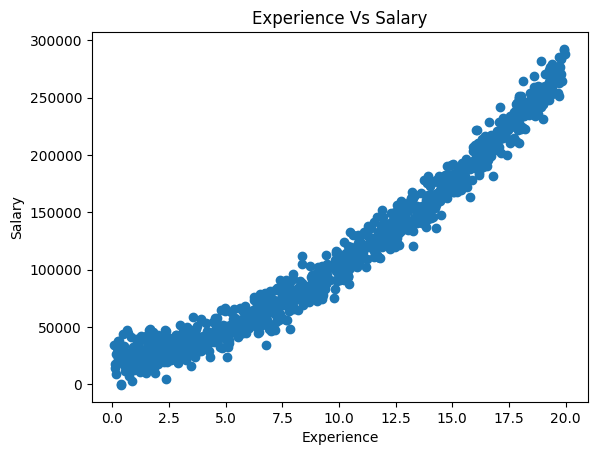

In [13]:
import matplotlib.pyplot as plt
plt.scatter(data['experience_years'],data['salary'])
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Experience Vs Salary')
plt.show()

In [14]:
X=data[['experience_years']]
y=data['salary']

In [16]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_poly,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
from sklearn.metrics import mean_squared_error,r2_score
y_pred=model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)

Mean Squared Error: 86222450.0357318
R2 Score: 0.9845168540773637


In [26]:
experience=float(input('Enter the experience '))
new_employee=pd.DataFrame({'experience_years':[experience]})
new_employee_poly=poly.transform(new_employee)
predicted_salary=model.predict(new_employee_poly)[0]
print(f"The predicted annual salary for an employee with {experience} years of experience is ₹{predicted_salary:,.2f}.")

Enter the experience  10


The predicted annual salary for an employee with 10.0 years of experience is ₹101,600.81.
